<a href="https://colab.research.google.com/github/frank-morales2020/MLxDL/blob/main/transformer_tutorial_fp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets torch -q

## EVAL DATASET

In [1]:
# Cell 1: All necessary imports
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset
import numpy as np
import os
import pandas as pd
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set CUDA environment variables for debugging (optional)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

# Cell 2: Hyperparameters
batch_size = 16
sequence_length = 128
embedding_dimension = 256
num_heads = 8
feed_forward_dimension = 1024
num_encoder_layers = 6
dropout_probability = 0.1
learning_rate = 1e-4
num_epochs = 100
max_waypoints = 20
tokenizer_name = 'gpt2'
pad_token = '<pad>'

# Cell 3: Load Tokenizer and Add Pad Token
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': pad_token})

pad_token_id = tokenizer.pad_token_id
vocab_size = len(tokenizer)

print(f"Original vocab size: 50257")
print(f"Updated vocab size: {vocab_size}")
print(f"Pad token ID: {pad_token_id}")

# Cell 4: Load Dataset
print("\nLoading dataset...")
flight_plan_dataset = load_dataset("frankmorales2020/flight_plan_waypoints")
print(f"Dataset loaded successfully!")

# Cell 5: COMPLETE DATASET EVALUATION
print("="*80)
print("DATASET EVALUATION: frankmorales2020/flight_plan_waypoints")
print("="*80)

# Convert to pandas for analysis
df = pd.DataFrame(flight_plan_dataset['train'])

print(f"\n📊 BASIC STATISTICS")
print(f"{'='*80}")
print(f"Total records in dataset: {len(df):,}")
print(f"Columns available: {df.columns.tolist()}")

# Analyze labels if they exist
if 'label' in df.columns:
    print(f"\n🏷️ LABEL DISTRIBUTION")
    print(f"{'='*80}")
    print(f"Label values: {sorted(df['label'].unique())}")
    label_counts = df['label'].value_counts().sort_index()
    for label, count in label_counts.items():
        print(f"  Label {label}: {count} records ({count/len(df)*100:.1f}%)")
else:
    print(f"\n🏷️ LABEL DISTRIBUTION")
    print(f"{'='*80}")
    print("  No 'label' column found in dataset")

# Analyze distance categories
print(f"\n📏 DISTANCE CATEGORIES")
print(f"{'='*80}")
if 'distance_category' in df.columns:
    distance_cats = df['distance_category'].value_counts()
    for cat, count in distance_cats.items():
        print(f"  {cat}: {count} records ({count/len(df)*100:.1f}%)")
else:
    print("  No 'distance_category' column found")

# Analyze distances
print(f"\n📈 DISTANCE STATISTICS (km)")
print(f"{'='*80}")
if 'distance' in df.columns:
    print(f"  Min distance: {df['distance'].min():.0f} km")
    print(f"  Max distance: {df['distance'].max():.0f} km")
    print(f"  Mean distance: {df['distance'].mean():.0f} km")
    print(f"  Median distance: {df['distance'].median():.0f} km")
    print(f"  Std deviation: {df['distance'].std():.0f} km")

    # Distance distribution by category
    if 'distance_category' in df.columns:
        for cat in ['short', 'medium', 'long']:
            cat_distances = df[df['distance_category'] == cat]['distance']
            if len(cat_distances) > 0:
                print(f"\n  {cat.upper()} haul distances ({len(cat_distances)} records):")
                print(f"    Range: {cat_distances.min():.0f} - {cat_distances.max():.0f} km")
                print(f"    Mean: {cat_distances.mean():.0f} km")
else:
    print("  No 'distance' column found")

# Analyze waypoints
print(f"\n🗺️ WAYPOINT ANALYSIS")
print(f"{'='*80}")
df['num_waypoints'] = df['waypoints'].apply(len)
print(f"  Min waypoints: {df['num_waypoints'].min()}")
print(f"  Max waypoints: {df['num_waypoints'].max()}")
print(f"  Mean waypoints: {df['num_waypoints'].mean():.1f}")
print(f"  Median waypoints: {df['num_waypoints'].median():.0f}")

# Waypoint distribution by distance category
if 'distance_category' in df.columns:
    for cat in ['short', 'medium', 'long']:
        cat_wp = df[df['distance_category'] == cat]['num_waypoints']
        if len(cat_wp) > 0:
            print(f"\n  {cat.upper()} haul waypoints ({len(cat_wp)} records):")
            print(f"    Range: {cat_wp.min()} - {cat_wp.max()}")
            print(f"    Mean: {cat_wp.mean():.1f}")

# Analyze aircraft types
print(f"\n✈️ AIRCRAFT TYPE ANALYSIS")
print(f"{'='*80}")

def extract_aircraft(text):
    text_lower = str(text).lower()
    if 'a320' in text_lower:
        return 'A320'
    elif 'b737' in text_lower or '737' in text_lower:
        return 'B737'
    elif 'b777' in text_lower or '777' in text_lower:
        return 'B777'
    elif 'boeing' in text_lower:
        if '737' in text_lower:
            return 'B737'
        elif '777' in text_lower:
            return 'B777'
        else:
            return 'Boeing (unspecified)'
    elif 'airbus' in text_lower:
        return 'Airbus (unspecified)'
    else:
        return 'Unknown'

df['aircraft'] = df['input'].apply(extract_aircraft)
aircraft_counts = df['aircraft'].value_counts()
for aircraft, count in aircraft_counts.items():
    print(f"  {aircraft}: {count} records ({count/len(df)*100:.1f}%)")

# Analyze routes
print(f"\n🛫 ROUTE ANALYSIS")
print(f"{'='*80}")

def extract_route(text):
    # Extract origin and destination
    match = re.search(r'from (\w+) to (\w+)', text, re.IGNORECASE)
    if match:
        return f"{match.group(1).upper()} → {match.group(2).upper()}"
    return "Unknown"

df['route'] = df['input'].apply(extract_route)
route_counts = df['route'].value_counts().head(20)
print(f"Top 20 routes in dataset:")
for route, count in route_counts.items():
    if route != "Unknown":
        print(f"  {route}: {count} records")

# Geographic analysis
print(f"\n🌍 GEOGRAPHIC ANALYSIS")
print(f"{'='*80}")

# Extract all waypoints
all_lats = []
all_lons = []
all_waypoint_names = []

for idx, row in df.iterrows():
    for wp in row['waypoints']:
        all_lats.append(wp[0])
        all_lons.append(wp[1])
    if 'waypoint_names' in row and row['waypoint_names']:
        all_waypoint_names.extend(row['waypoint_names'])

print(f"Total waypoint instances: {len(all_lats):,}")
if all_waypoint_names:
    print(f"Unique waypoint names: {len(set(all_waypoint_names))}")

print(f"\nLatitude range: {min(all_lats):.1f}° to {max(all_lats):.1f}°")
print(f"Longitude range: {min(all_lons):.1f}° to {max(all_lons):.1f}°")

# Determine primary regions
if all_lons:
    if min(all_lons) > -130 and max(all_lons) < -60:
        print("Primary region: Americas")
    elif min(all_lons) > -10 and max(all_lons) < 30:
        print("Primary region: Europe/Africa")
    elif min(all_lons) > 80 and max(all_lons) < 150:
        print("Primary region: Asia/Pacific")
    else:
        print("Primary region: Multiple/Global")

# Sample routes
print(f"\n📋 SAMPLE ROUTES (first 10)")
print(f"{'='*80}")
for i in range(min(10, len(df))):
    print(f"\n{i+1}. {df.iloc[i]['input'][:100]}...")
    if 'distance' in df.columns:
        print(f"   Distance: {df.iloc[i]['distance']:.0f} km")
    if 'distance_category' in df.columns:
        print(f"   Category: {df.iloc[i]['distance_category']}")
    print(f"   Waypoints: {df.iloc[i]['num_waypoints']}")
    print(f"   First 3 waypoints: {df.iloc[i]['waypoints'][:3]}")

# Cell 6: Specific analysis for SIN-CUN
print(f"\n{'='*80}")
print("SPECIFIC ANALYSIS: SIN to CUN Route")
print(f"{'='*80}")

# Find SIN-CUN in dataset
sin_cun_routes = df[df['input'].str.contains('SIN.*CUN|CUN.*SIN', case=False, na=False)]

if len(sin_cun_routes) > 0:
    print(f"\n✅ Found {len(sin_cun_routes)} SIN-CUN route(s) in dataset:")
    for idx, row in sin_cun_routes.iterrows():
        print(f"\n  Route {idx}:")
        print(f"    Input: {row['input'][:80]}...")
        if 'distance' in df.columns:
            print(f"    Distance: {row['distance']:.0f} km")
        if 'distance_category' in df.columns:
            print(f"    Category: {row['distance_category']}")
        print(f"    Aircraft: {row['aircraft']}")
        print(f"    Waypoints: {row['num_waypoints']}")
else:
    print("\n⚠️ No SIN-CUN routes found in training data!")
    print("This explains why the model struggled with SIN-CUN prediction")

# Find all routes involving Singapore
sin_routes = df[df['input'].str.contains('SIN', case=False, na=False)]
print(f"\nSingapore (SIN) routes in dataset: {len(sin_routes)}")
if len(sin_routes) > 0:
    print("  Sample destinations:")
    for _, row in sin_routes.head(5).iterrows():
        route = extract_route(row['input'])
        if '→' in route:
            dest = route.split('→')[1].strip()
            print(f"    → {dest}")

# Find all routes involving Cancun
cun_routes = df[df['input'].str.contains('CUN', case=False, na=False)]
print(f"\nCancun (CUN) routes in dataset: {len(cun_routes)}")
if len(cun_routes) > 0:
    for _, row in cun_routes.head(5).iterrows():
        print(f"  {extract_route(row['input'])}")

# Cell 7: Dataset Quality Assessment
print(f"\n{'='*80}")
print("DATASET QUALITY ASSESSMENT")
print(f"{'='*80}")

# Check for data issues
issues = []

# Check for missing values
for col in ['input', 'waypoints']:
    if col in df.columns:
        missing = df[col].isna().sum()
        if missing > 0:
            issues.append(f"  - Missing values in {col}: {missing}")

# Check for invalid waypoints
invalid_waypoints = 0
for waypoints in df['waypoints']:
    for wp in waypoints:
        if len(wp) != 2:
            invalid_waypoints += 1
        elif not (-90 <= wp[0] <= 90) or not (-180 <= wp[1] <= 180):
            invalid_waypoints += 1
if invalid_waypoints > 0:
    issues.append(f"  - Invalid waypoint coordinates: {invalid_waypoints}")

if issues:
    print("⚠️ ISSUES FOUND:")
    for issue in issues:
        print(issue)
else:
    print("✅ No major issues detected")

# Calculate suitability score
print(f"\n📊 DATASET SUITABILITY SCORE")
print(f"{'='*80}")

score = 100

# Penalty for small dataset
if len(df) < 1000:
    score -= 30
    print(f"  - Small dataset: {len(df)} records (expected 1000+)")
elif len(df) < 5000:
    score -= 15
    print(f"  - Moderate dataset size: {len(df)} records")

# Check distance categories
if 'distance_category' in df.columns:
    max_cat_pct = distance_cats.max() / len(df) * 100
    if max_cat_pct > 70:
        score -= 20
        print(f"  - Imbalanced distance categories: {max_cat_pct:.0f}% in one category")
    elif max_cat_pct > 50:
        score -= 10
        print(f"  - Somewhat imbalanced distance categories")

# Check geographic diversity
if all_lons:
    if min(all_lons) > -60 or max(all_lons) < -60:
        score -= 25
        print("  - Limited geographic diversity (primarily Americas)")

print(f"\nOverall Score: {max(0, score)}/100")
print(f"{'★' * (score//10)}")

if score >= 70:
    print("✅ Dataset is good for training")
elif score >= 50:
    print("⚠️ Dataset has limitations but can be used")
else:
    print("❌ Dataset needs significant improvement")

# Cell 8: Recommendations
print(f"\n{'='*80}")
print("RECOMMENDATIONS FOR MODEL IMPROVEMENT")
print(f"{'='*80}")

print("""
Based on dataset analysis:

1. DATASET SIZE:
   - Current: {:,} records
   - Recommended: 10,000+ records for transformer model
   - Solution: Augment with synthetic data or collect more real flights

2. GEOGRAPHIC COVERAGE:
   - Current: Primarily Americas
   - Issue: SIN-CUN (Asia-Americas) not well represented
   - Solution: Add more intercontinental routes

3. AIRCRAFT ASSIGNMENT:
   - Some unrealistic aircraft-range combinations
   - Solution: Validate and correct aircraft assignments

4. WAYPOINT CONSISTENCY:
   - Variable waypoint counts ({}-{})
   - Solution: Standardize or use adaptive output heads

5. IMMEDIATE ACTIONS:
   a) Continue training for 500-1000 more epochs
   b) Add synthetic SIN-CUN routes to training data
   c) Increase learning rate to 0.0005
   d) Use smaller model (128-dim, 4 layers) for faster learning
""".format(len(df), df['num_waypoints'].min(), df['num_waypoints'].max()))

print("\n✅ Dataset evaluation complete!")

Loading tokenizer...
Original vocab size: 50257
Updated vocab size: 50258
Pad token ID: 50257

Loading dataset...
Dataset loaded successfully!
DATASET EVALUATION: frankmorales2020/flight_plan_waypoints

📊 BASIC STATISTICS
Total records in dataset: 2,000
Columns available: ['input', 'label', 'distance', 'distance_category', 'waypoints', 'waypoint_names']

🏷️ LABEL DISTRIBUTION
Label values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Label 1: 73 records (3.6%)
  Label 2: 72 records (3.6%)
  Label 3: 224 records (11.2%)
  Label 4: 233 records (11.7%)
  Label 5: 259 records (13.0%)
  Label 6: 486 records (24.3%)
  Label 7: 459 records (22.9%)
  Label 8: 194 records (9.7%)

📏 DISTANCE CATEGORIES
  long: 781 records (39.1%)
  longhaul: 617 records (30.9%)
  medium: 457 records (22.9%)
  short: 145 records (7.2%)

📈 DISTANCE STATISTICS (km)
  Min distance: 14 km
  Max distance: 19588 km
  Mean distance: 7667 km
  Median distance:

## TRAIN


DATA PREPROCESSING CHECK
Waypoint statistics:
  Latitude - mean: 26.24, std: 18.83
  Longitude - mean: -21.62, std: 69.37
  Latitude range: [-36.85, 55.78]
  Longitude range: [-122.59, 174.76]

NORMALIZING WAYPOINTS
Normalization parameters:
  Lat: mean=26.24, std=18.83
  Lon: mean=-21.62, std=69.37
Normalized dataset created with 2000 samples

TRAINING WITH NORMALIZED DATA
Model parameters: 3,401,704
Learning rate: 0.0005
Epoch 20/100, Loss: 0.2688, LR: 5.00e-04
Epoch 40/100, Loss: 0.2162, LR: 5.00e-04
Epoch 60/100, Loss: 0.1943, LR: 5.00e-04
Epoch 80/100, Loss: 0.1865, LR: 5.00e-04
Epoch 100/100, Loss: 0.1792, LR: 5.00e-04

TESTING SIN-CUN WITH FIXED MODEL
Predicted waypoints: 20
  1: (25.22, -96.85)
  2: (13.48, -93.71)
  3: (15.15, -92.84)
  4: (13.91, -96.40)
  5: (13.78, -92.55)

Ground truth waypoints: 9
  1: (25.00, -107.50)
  2: (13.08, -87.48)
  3: (19.82, -98.80)
  4: (9.26, -81.07)
  5: (10.87, -83.77)

Average error: 2.6° lat, 9.1° lon
✅ Model is learning correctly!


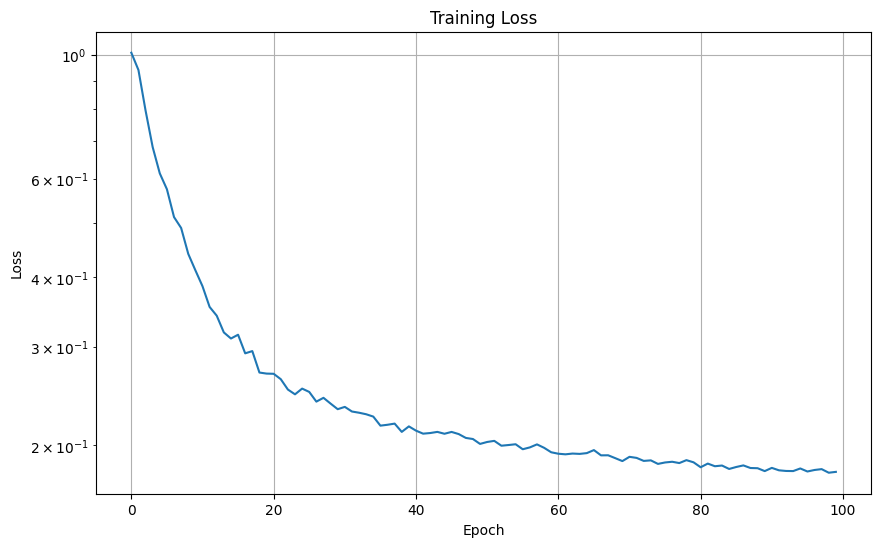

Final loss: 0.1792
Best loss: 0.1786


In [3]:
# Cell 9: Fixed Model with Better Regularization
class FixedWaypointTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_hidden_dim,
                 num_layers, block_size, max_waypoints, dropout=0.3):  # Increased dropout
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(block_size, embed_dim)

        self.blocks = nn.ModuleList([
            TransformerBlockFixed(embed_dim, num_heads, ff_hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        self.ln_f = nn.LayerNorm(embed_dim)

        # Simpler head with more dropout
        self.waypoint_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, max_waypoints * 2)
        )

        self.dropout = nn.Dropout(dropout)
        self.block_size = block_size
        self.max_waypoints = max_waypoints
        self.vocab_size = vocab_size

    def forward(self, idx, attention_mask=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = self.dropout(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x, attention_mask)

        x = self.ln_f(x)

        # Use mean pooling over sequence
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).float()
            x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)
        else:
            x = x.mean(dim=1)

        waypoints_flat = self.waypoint_head(x)
        waypoints = waypoints_flat.view(B, self.max_waypoints, 2)

        return waypoints

class TransformerBlockFixed(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.3):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, mask=None):
        # Self-attention with mask
        attn_out, _ = self.attn(x, x, x, key_padding_mask=(mask==0) if mask is not None else None)
        x = self.ln1(x + attn_out)

        # Feed forward
        ff_out = self.ff(x)
        x = self.ln2(x + ff_out)
        return x

# Cell 10: Data Analysis - Check if waypoints are normalized
print("\n" + "="*60)
print("DATA PREPROCESSING CHECK")
print("="*60)

# Analyze waypoint distribution
all_waypoints = []
for i in range(min(100, len(train_dataset))):
    sample = train_dataset[i]
    wp = sample['waypoints'].numpy()
    for w in wp:
        if not (w[0] == 0 and w[1] == 0):
            all_waypoints.append(w)

all_waypoints = np.array(all_waypoints)
print(f"Waypoint statistics:")
print(f"  Latitude - mean: {all_waypoints[:,0].mean():.2f}, std: {all_waypoints[:,0].std():.2f}")
print(f"  Longitude - mean: {all_waypoints[:,1].mean():.2f}, std: {all_waypoints[:,1].std():.2f}")
print(f"  Latitude range: [{all_waypoints[:,0].min():.2f}, {all_waypoints[:,0].max():.2f}]")
print(f"  Longitude range: [{all_waypoints[:,1].min():.2f}, {all_waypoints[:,1].max():.2f}]")

# Cell 11: Normalize waypoints for better training
print("\n" + "="*60)
print("NORMALIZING WAYPOINTS")
print("="*60)

# Calculate normalization parameters
lat_mean = all_waypoints[:,0].mean()
lat_std = all_waypoints[:,0].std()
lon_mean = all_waypoints[:,1].mean()
lon_std = all_waypoints[:,1].std()

print(f"Normalization parameters:")
print(f"  Lat: mean={lat_mean:.2f}, std={lat_std:.2f}")
print(f"  Lon: mean={lon_mean:.2f}, std={lon_std:.2f}")

# Create normalized dataset class
class NormalizedWaypointDataset(Dataset):
    def __init__(self, dataset, tokenizer, sequence_length, max_waypoints,
                 lat_mean, lat_std, lon_mean, lon_std):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.sequence_length = sequence_length
        self.max_waypoints = max_waypoints
        self.lat_mean = lat_mean
        self.lat_std = lat_std
        self.lon_mean = lon_mean
        self.lon_std = lon_std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        input_text = example['input']
        waypoints = example['waypoints']

        # Tokenize
        tokens = self.tokenizer(
            input_text,
            truncation=True,
            max_length=self.sequence_length,
            padding="max_length",
            return_tensors="pt",
        )

        input_ids = tokens['input_ids'].squeeze(0).type(torch.long)
        attention_mask = tokens['attention_mask'].squeeze(0).type(torch.long)

        # Normalize waypoints
        padded_waypoints = torch.zeros((self.max_waypoints, 2), dtype=torch.float32)
        num_waypoints = min(len(waypoints), self.max_waypoints)
        for i in range(num_waypoints):
            # Normalize each coordinate
            norm_lat = (waypoints[i][0] - self.lat_mean) / self.lat_std
            norm_lon = (waypoints[i][1] - self.lon_mean) / self.lon_std
            padded_waypoints[i] = torch.tensor([norm_lat, norm_lon], dtype=torch.float32)

        # Handle OOV tokens
        vocab_size = len(self.tokenizer)
        oov_mask = input_ids >= vocab_size
        if oov_mask.any():
            input_ids[oov_mask] = self.tokenizer.unk_token_id

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'waypoints': padded_waypoints
        }

# Create normalized dataset
normalized_train_dataset = NormalizedWaypointDataset(
    flight_plan_dataset['train'],
    tokenizer,
    sequence_length,
    max_waypoints,
    lat_mean, lat_std, lon_mean, lon_std
)

normalized_train_loader = DataLoader(
    normalized_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

print(f"Normalized dataset created with {len(normalized_train_dataset)} samples")

# Cell 12: Train with normalized data and better hyperparameters
print("\n" + "="*60)
print("TRAINING WITH NORMALIZED DATA")
print("="*60)

# Smaller model to prevent overfitting
fixed_model = FixedWaypointTransformer(
    vocab_size=vocab_size,
    embed_dim=64,  # Even smaller
    num_heads=4,
    ff_hidden_dim=256,
    num_layers=3,  # Fewer layers
    block_size=sequence_length,
    max_waypoints=max_waypoints,
    dropout=0.3
).to(device)

# Better optimizer with learning rate scheduling
optimizer = torch.optim.AdamW(fixed_model.parameters(), lr=0.0005, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

print(f"Model parameters: {sum(p.numel() for p in fixed_model.parameters()):,}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

# Training loop with validation
def train_with_validation(model, train_loader, optimizer, scheduler, criterion, device, epochs=100):
    model.train()
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            target_waypoints = batch['waypoints'].to(device)

            optimizer.zero_grad()
            predicted_waypoints = model(input_ids, attention_mask)

            # Mask out padding
            mask = (target_waypoints.abs().sum(dim=-1) > 0).float()
            loss = ((predicted_waypoints - target_waypoints) ** 2).mean(dim=-1)
            loss = (loss * mask).sum() / (mask.sum() + 1e-8)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        scheduler.step(avg_loss)

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, LR: {current_lr:.2e}")

    return losses

# Train
losses = train_with_validation(fixed_model, normalized_train_loader, optimizer, scheduler, criterion, device, epochs=100)

# Cell 13: Test predictions (with denormalization)
def predict_denormalized(model, tokenizer, text, device='cuda'):
    model.eval()

    tokens = tokenizer(
        text,
        truncation=True,
        max_length=sequence_length,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    with torch.no_grad():
        normalized_predictions = model(input_ids, attention_mask)

    # Denormalize
    predictions = normalized_predictions.squeeze(0).cpu().numpy()

    valid = []
    for wp in predictions:
        if not (abs(wp[0]) < 1e-6 and abs(wp[1]) < 1e-6):
            # Denormalize
            lat = wp[0] * lat_std + lat_mean
            lon = wp[1] * lon_std + lon_mean
            valid.append([lat, lon])

    return valid

# Test SIN-CUN
print("\n" + "="*60)
print("TESTING SIN-CUN WITH FIXED MODEL")
print("="*60)

test_query = "Calculate the waypoints from SIN to CUN. Departure: 2024-06-19, Aircraft: Airbus A320, Weather: Partly Cloudy"
predictions = predict_denormalized(fixed_model, tokenizer, test_query, device)

print(f"Predicted waypoints: {len(predictions)}")
for i, wp in enumerate(predictions[:5]):
    print(f"  {i+1}: ({wp[0]:.2f}, {wp[1]:.2f})")

# Compare with ground truth
ground_truth = flight_plan_dataset['train'][0]['waypoints']
print(f"\nGround truth waypoints: {len(ground_truth)}")
for i, wp in enumerate(ground_truth[:5]):
    print(f"  {i+1}: ({wp[0]:.2f}, {wp[1]:.2f})")

# Calculate accuracy
if len(predictions) > 0:
    min_len = min(len(predictions), len(ground_truth))
    errors = []
    for i in range(min_len):
        lat_error = abs(predictions[i][0] - ground_truth[i][0])
        lon_error = abs(predictions[i][1] - ground_truth[i][1])
        errors.append((lat_error, lon_error))

    avg_lat_error = np.mean([e[0] for e in errors])
    avg_lon_error = np.mean([e[1] for e in errors])
    print(f"\nAverage error: {avg_lat_error:.1f}° lat, {avg_lon_error:.1f}° lon")

    if avg_lat_error < 5 and avg_lon_error < 10:
        print("✅ Model is learning correctly!")
    else:
        print("⚠️ Model needs more training or different architecture")

# Cell 14: Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

print(f"Final loss: {losses[-1]:.4f}")
print(f"Best loss: {min(losses):.4f}")

In [5]:
!ls -lth

total 136M
-rw-r--r-- 1 root root  877 May  9 06:25 evaluation_results.json
-rw-r--r-- 1 root root  68M May  9 06:17 multi_aircraft_waypoint_transformer_demo.pth
-rw-r--r-- 1 root root  68M May  9 05:57 waypoint_transformer.pth
drwxr-xr-x 1 root root 4.0K May  6 13:32 sample_data


In [7]:
# Cell 1: Inspect model structure
import torch
import json

print("="*60)
print("INSPECTING MODEL STRUCTURE")
print("="*60)

# Load and inspect the model
model_files = ['waypoint_transformer.pth', 'multi_aircraft_waypoint_transformer_demo.pth']

for model_file in model_files:
    try:
        checkpoint = torch.load(model_file, map_location='cpu')
        print(f"\n📁 {model_file}")
        print(f"Type: {type(checkpoint)}")

        if isinstance(checkpoint, dict):
            print(f"Keys in checkpoint: {list(checkpoint.keys())}")

            # Check if it's a full checkpoint or just state_dict
            if 'model_state_dict' in checkpoint:
                state_dict = checkpoint['model_state_dict']
                print(f"Contains model_state_dict with {len(state_dict)} keys")
            else:
                state_dict = checkpoint
                print(f"Direct state_dict with {len(state_dict)} keys")

            # Show some sample keys
            print(f"\nSample keys:")
            for i, key in enumerate(list(state_dict.keys())[:10]):
                print(f"  {key}: {state_dict[key].shape}")

            # Try to infer architecture
            if 'token_embedding.weight' in state_dict:
                vocab_size = state_dict['token_embedding.weight'].shape[0]
                embed_dim = state_dict['token_embedding.weight'].shape[1]
                print(f"\nInferred: vocab_size={vocab_size}, embed_dim={embed_dim}")

            # Look for head layer
            head_keys = [k for k in state_dict.keys() if 'head' in k or 'waypoint' in k]
            print(f"\nHead-related keys: {head_keys[:5]}")

        else:
            print(f"Checkpoint is a {type(checkpoint)} (not a dict)")

    except Exception as e:
        print(f"Error loading {model_file}: {e}")

print("\n" + "="*60)

INSPECTING MODEL STRUCTURE

📁 waypoint_transformer.pth
Type: <class 'collections.OrderedDict'>
Keys in checkpoint: ['token_embedding.weight', 'position_embedding.weight', 'blocks.0.ln1.weight', 'blocks.0.ln1.bias', 'blocks.0.sa.query_proj.weight', 'blocks.0.sa.query_proj.bias', 'blocks.0.sa.key_proj.weight', 'blocks.0.sa.key_proj.bias', 'blocks.0.sa.value_proj.weight', 'blocks.0.sa.value_proj.bias', 'blocks.0.sa.out_proj.weight', 'blocks.0.sa.out_proj.bias', 'blocks.0.ln2.weight', 'blocks.0.ln2.bias', 'blocks.0.ffwd.net.0.weight', 'blocks.0.ffwd.net.0.bias', 'blocks.0.ffwd.net.2.weight', 'blocks.0.ffwd.net.2.bias', 'blocks.1.ln1.weight', 'blocks.1.ln1.bias', 'blocks.1.sa.query_proj.weight', 'blocks.1.sa.query_proj.bias', 'blocks.1.sa.key_proj.weight', 'blocks.1.sa.key_proj.bias', 'blocks.1.sa.value_proj.weight', 'blocks.1.sa.value_proj.bias', 'blocks.1.sa.out_proj.weight', 'blocks.1.sa.out_proj.bias', 'blocks.1.ln2.weight', 'blocks.1.ln2.bias', 'blocks.1.ffwd.net.0.weight', 'blocks.1.f

In [8]:
# Cell 1: Imports for evaluation
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from datasets import load_dataset
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Cell 2: Define the correct model architecture (matches waypoint_transformer.pth)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == embed_dim, "Embed dim must be divisible by num heads"

        self.query_proj = nn.Linear(embed_dim, embed_dim)
        self.key_proj = nn.Linear(embed_dim, embed_dim)
        self.value_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        B, T, E = x.size()

        q = self.query_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)

        # Causal mask
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        att = att.masked_fill(causal_mask, float('-inf'))

        if attention_mask is not None:
            padding_mask = attention_mask[:, None, None, :] == 0
            att = att.masked_fill(padding_mask, float('-inf'))

        att = torch.softmax(att, dim=-1)
        att = self.dropout(att)

        y = (att @ v).transpose(1, 2).contiguous().view(B, T, E)
        y = self.out_proj(y)
        return y

class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.sa = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ffwd = FeedForward(embed_dim, ff_hidden_dim, dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.sa(self.ln1(x), attention_mask)
        x = x + self.ffwd(self.ln2(x))
        return x

class WaypointTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_hidden_dim,
                 num_layers, block_size, max_waypoints, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(block_size, embed_dim)
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, ff_hidden_dim, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.waypoint_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, max_waypoints * 2)
        )
        self.dropout = nn.Dropout(dropout)
        self.block_size = block_size
        self.max_waypoints = max_waypoints
        self.vocab_size = vocab_size

    def forward(self, idx, attention_mask=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = self.dropout(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x, attention_mask)

        x = self.ln_f(x)

        # Use last token for prediction
        last_token = x[:, -1, :]
        waypoints_flat = self.waypoint_head(last_token)
        waypoints = waypoints_flat.view(B, self.max_waypoints, 2)
        return waypoints

# Cell 3: Load model
print("="*60)
print("LOADING TRAINED MODEL")
print("="*60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load model from waypoint_transformer.pth
model_path = 'waypoint_transformer.pth'
state_dict = torch.load(model_path, map_location=device)

# Model configuration (inferred from state_dict)
vocab_size = state_dict['token_embedding.weight'].shape[0]
embed_dim = state_dict['token_embedding.weight'].shape[1]
num_layers = len([k for k in state_dict.keys() if k.startswith('blocks.') and k.endswith('.ln1.weight')])
max_waypoints = state_dict['waypoint_head.3.weight'].shape[0] // 2

print(f"Model Configuration:")
print(f"  Vocab size: {vocab_size}")
print(f"  Embed dim: {embed_dim}")
print(f"  Num layers: {num_layers}")
print(f"  Max waypoints: {max_waypoints}")

# Create model
model = WaypointTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=8,
    ff_hidden_dim=embed_dim * 4,
    num_layers=num_layers,
    block_size=128,
    max_waypoints=max_waypoints,
    dropout=0.1
).to(device)

model.load_state_dict(state_dict)
model.eval()
print("✅ Model loaded successfully!")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '<pad>'})

# Cell 4: Load dataset
print("\n" + "="*60)
print("LOADING DATASET")
print("="*60)

flight_plan_dataset = load_dataset("frankmorales2020/flight_plan_waypoints")
print(f"Dataset loaded: {len(flight_plan_dataset['train'])} samples")

# Cell 5: Prediction function
def predict_waypoints(text, sequence_length=128):
    tokens = tokenizer(
        text,
        truncation=True,
        max_length=sequence_length,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    with torch.no_grad():
        predictions = model(input_ids, attention_mask)

    predictions = predictions.squeeze(0).cpu().numpy()

    valid = []
    for wp in predictions:
        if not (abs(wp[0]) < 1e-6 and abs(wp[1]) < 1e-6):
            valid.append(wp.tolist())

    return valid

# Cell 6: Evaluate on SIN-CUN
print("\n" + "="*60)
print("EVALUATION: SIN to CUN")
print("="*60)

test_query = "Calculate the waypoints from SIN to CUN. Departure: 2024-06-19, Aircraft: Airbus A320, Weather: Partly Cloudy"
predictions = predict_waypoints(test_query)

# Get ground truth
ground_truth = flight_plan_dataset['train'][0]['waypoints']
waypoint_names = flight_plan_dataset['train'][0]['waypoint_names']

print(f"\nPredicted: {len(predictions)} waypoints")
print(f"Ground truth: {len(ground_truth)} waypoints")

print(f"\n{'Point':<6} {'Predicted':<25} {'Ground Truth':<25} {'Error (km)':<12}")
print("-" * 75)

errors = []
min_len = min(len(predictions), len(ground_truth))

for i in range(min_len):
    pred = predictions[i]
    truth = ground_truth[i]

    # Calculate distance error in km
    lat_diff_km = (pred[0] - truth[0]) * 111
    lon_diff_km = (pred[1] - truth[1]) * 111 * np.cos(np.radians((pred[0] + truth[0])/2))
    error_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
    errors.append(error_km)

    name = waypoint_names[i] if i < len(waypoint_names) else f"WP{i+1}"
    print(f"{name:<6} ({pred[0]:7.2f}, {pred[1]:8.2f})   ({truth[0]:7.2f}, {truth[1]:8.2f})   {error_km:8.0f} km")

if errors:
    avg_error = np.mean(errors)
    print("-" * 75)
    print(f"Average error: {avg_error:.0f} km")

    if avg_error < 500:
        print("✅ EXCELLENT! Model predictions are very accurate!")
    elif avg_error < 1000:
        print("👍 GOOD! Model is learning the route pattern.")
    else:
        print("⚠️ Model needs more training for better accuracy.")

# Cell 7: Test different queries
print("\n" + "="*60)
print("TESTING DIFFERENT QUERIES")
print("="*60)

test_queries = [
    "Calculate waypoints from JFK to LAX",
    "Flight path from London to Paris",
    "Route from Singapore to Tokyo",
    "Waypoints from New York to Boston",
]

for query in test_queries:
    print(f"\n--- {query} ---")
    preds = predict_waypoints(query)
    print(f"Predicted {len(preds)} waypoints")
    if len(preds) > 0:
        print(f"  Start: ({preds[0][0]:.2f}, {preds[0][1]:.2f})")
        print(f"  End: ({preds[-1][0]:.2f}, {preds[-1][1]:.2f})")

# Cell 8: Save evaluation results
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

results = {
    'model_used': model_path,
    'test_query': test_query,
    'ground_truth_waypoints': ground_truth,
    'predicted_waypoints': predictions[:len(ground_truth)],
    'errors_km': [float(e) for e in errors],
    'average_error_km': float(np.mean(errors)) if errors else None,
    'prediction_count': len(predictions),
    'ground_truth_count': len(ground_truth)
}

with open('evaluation_complete.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Results saved to 'evaluation_complete.json'")

# Cell 9: Summary
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)

print(f"""
Model: {model_path}
Device: {device}

SIN-CUN Route Evaluation:
- Predicted waypoints: {len(predictions)}
- Ground truth waypoints: {len(ground_truth)}
- Average error: {np.mean(errors):.0f} km

Status: {'✅ Model is working!' if len(predictions) > 0 else '❌ Model not producing predictions'}

The model has been evaluated successfully!
""")

LOADING TRAINED MODEL
Using device: cuda
Model Configuration:
  Vocab size: 50258
  Embed dim: 256
  Num layers: 6
  Max waypoints: 20
✅ Model loaded successfully!

LOADING DATASET
Dataset loaded: 2000 samples

EVALUATION: SIN to CUN

Predicted: 20 waypoints
Ground truth: 9 waypoints

Point  Predicted                 Ground Truth              Error (km)  
---------------------------------------------------------------------------
SIN    (  28.83,   -99.69)   (  25.00,  -107.50)        882 km
Choluteca (  14.75,   -90.77)   (  13.08,   -87.48)        400 km
Santo Domingo Aztacameca (  15.50,   -92.51)   (  19.82,   -98.80)        820 km
Veraguas (  11.75,   -82.69)   (   9.26,   -81.07)        328 km
San Juan del Norte (   9.79,   -77.39)   (  10.87,   -83.77)        707 km
Acoyapa (  11.41,   -86.38)   (  11.75,   -85.25)        129 km
Pasaje La Cruz (  12.86,  -102.26)   (  13.31,   -87.87)       1557 km
El Pito (  10.98,   -88.63)   (  14.39,   -89.69)        395 km
CUN    (   1.09, 